In [83]:
import subprocess
import os
import sys
import math
import random
import re
import statistics
import time

# Iterative Sequential

In [84]:
import subprocess
import os
import random
import re
import statistics
import time
import csv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [85]:
CPP_FILE      = "/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/cooley_tukey_iterative.cpp"
BINARY        = "./fft_it_bin"
NUM_RUNS      = 20
COMPILE_FLAGS = ["-O2", "-std=c++17"]
CSV_FILE      = "sequential_iterative_fft.csv"

SIGNAL_LENGTHS = [2**p for p in range(1, 21)]  # 2^1 … 2^20

In [86]:


plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Compile ──────────────────────────────────
def step_compile():
    assert os.path.isfile(CPP_FILE), f"{CPP_FILE} not found"
    cmd = ["g++", CPP_FILE, "-o", BINARY] + COMPILE_FLAGS
    print("Compiling:", " ".join(cmd))
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(res.stderr)
    print("[OK] Compiled\n")

# ── Input generation ─────────────────────────
_cache = {}

def build_input(signal_length: int) -> str:
    if signal_length not in _cache:
        random.seed(signal_length)
        sig = [round(random.uniform(-100, 100), 6) for _ in range(signal_length)]
        _cache[signal_length] = "\n".join(map(str, sig))
    return f"{signal_length}\n{_cache[signal_length]}"

# ── Parsing ──────────────────────────────────
def parse_time(output: str):
    m = re.search(r"Time:\s*([\d.eE+\-]+)\s*seconds", output)
    return float(m.group(1)) if m else None

def run_once(stdin_data: str):
    try:
        r = subprocess.run(
            [BINARY],
            input=stdin_data,
            capture_output=True,
            text=True,
            timeout=120
        )
        return parse_time(r.stdout) if r.returncode == 0 else None
    except subprocess.TimeoutExpired:
        return None

# ── Benchmark ────────────────────────────────
def run_benchmark(length: int):
    data = build_input(length)
    run_once(data)  # warm-up

    times = [t for _ in range(NUM_RUNS)
             if (t := run_once(data)) is not None]

    if not times:
        return dict(length=length, avg=None, stdev=None, min=None, max=None, valid=0)

    return dict(
        length=length,
        avg=statistics.mean(times),
        stdev=statistics.stdev(times) if len(times) > 1 else 0.0,
        min=min(times),
        max=max(times),
        valid=len(times),
    )

def step_sweep():
    results = []
    t0 = time.time()

    print(f"Running sequential benchmark ({NUM_RUNS} runs each)\n")

    for i, length in enumerate(SIGNAL_LENGTHS, 1):
        elapsed = time.time() - t0
        print(f"[{i}/{len(SIGNAL_LENGTHS)}] N={length:<8} elapsed={elapsed:6.1f}s", end="  ")

        r = run_benchmark(length)
        results.append(r)

        if r["avg"] is not None:
            print(f"avg={r['avg']:.6f}s")
        else:
            print("FAILED")

    print(f"\nDone in {time.time() - t0:.1f}s")
    return results

# ── Save CSV ─────────────────────────────────
def step_save_csv(results):
    with open(CSV_FILE, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["length", "avg", "stdev", "min", "max", "valid"])
        writer.writeheader()
        writer.writerows(results)
    print(f"[CSV] Saved → {CSV_FILE}\n")

# ── Plot ─────────────────────────────────────
def plot_results(results):
    rows = [r for r in results if r["avg"] is not None]

    xi = list(range(len(rows)))
    xlabs = [f"2^{r['length'].bit_length()-1}" for r in rows]

    fig, ax = plt.subplots(figsize=(11, 5))

    ax.fill_between(xi,
                    [r["min"] for r in rows],
                    [r["max"] for r in rows],
                    alpha=0.2,
                    label="min–max")

    ax.plot(xi,
            [r["avg"] for r in rows],
            "o-",
            linewidth=2,
            label="average")

    ax.set_xticks(xi)
    ax.set_xticklabels(xlabs, rotation=45)
    ax.set_xlabel("Signal Length (N)")
    ax.set_ylabel("Time (seconds)")
    ax.set_title("Sequential FFT: Time vs Input Size")

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2e"))

    ax.legend()
    plt.tight_layout()
    plt.show()

# ── Main ─────────────────────────────────────


In [87]:
step_compile()
results = step_sweep()

Compiling: g++ /Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/cooley_tukey_iterative.cpp -o ./fft_it_bin -O2 -std=c++17
[OK] Compiled

Running sequential benchmark (20 runs each)

[1/20] N=2        elapsed=   0.0s  avg=0.000000s
[2/20] N=4        elapsed=   0.7s  avg=0.000000s
[3/20] N=8        elapsed=   0.7s  avg=0.000000s
[4/20] N=16       elapsed=   0.8s  avg=0.000001s
[5/20] N=32       elapsed=   0.8s  avg=0.000001s
[6/20] N=64       elapsed=   0.9s  avg=0.000001s
[7/20] N=128      elapsed=   0.9s  avg=0.000002s
[8/20] N=256      elapsed=   1.0s  avg=0.000003s
[9/20] N=512      elapsed=   1.0s  avg=0.000006s
[10/20] N=1024     elapsed=   1.1s  avg=0.000014s
[11/20] N=2048     elapsed=   1.2s  avg=0.000036s
[12/20] N=4096     elapsed=   1.3s  avg=0.000073s
[13/20] N=8192     elapsed=   1.4s  avg=0.000145s
[14/20] N=16384    elapsed=   1.7s  avg=0.000310s
[15/20] N=32768    elapsed=   2.2s  avg=0.000659s
[16/20] N=65536    elapsed=   3.0s  avg=0.001417s
[17/20] N=131072

[CSV] Saved → sequential_iterative_fft.csv



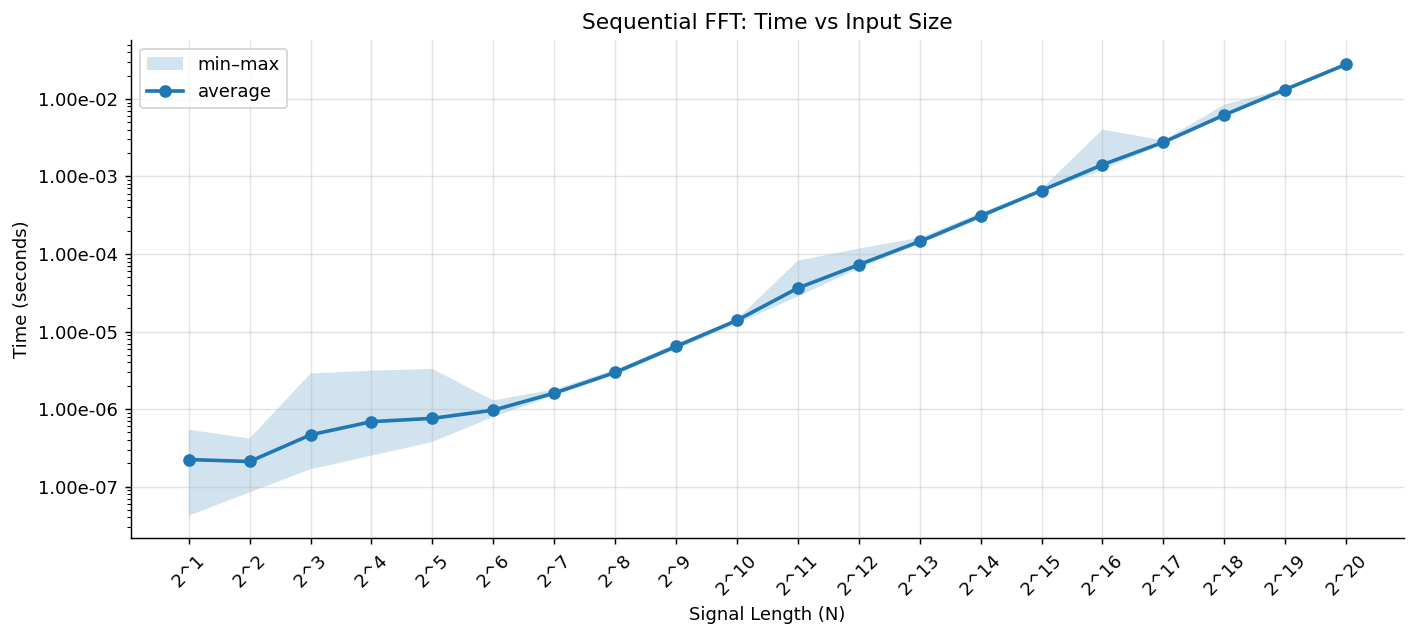

In [88]:
step_save_csv(results)
plot_results(results)

# RecursivenSequential

In [89]:
import subprocess
import os
import random
import re
import statistics
import time
import csv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [90]:
CPP_FILE      = "/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/cooley_tukey_sequential.cpp"
BINARY        = "./fft_seq_bin"
NUM_RUNS      = 20
COMPILE_FLAGS = ["-O2", "-std=c++17"]
CSV_FILE      = "sequential_fft.csv"

SIGNAL_LENGTHS = [2**p for p in range(1, 21)]  # 2^1 … 2^20

In [91]:


plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Compile ──────────────────────────────────
def step_compile():
    assert os.path.isfile(CPP_FILE), f"{CPP_FILE} not found"
    cmd = ["g++", CPP_FILE, "-o", BINARY] + COMPILE_FLAGS
    print("Compiling:", " ".join(cmd))
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(res.stderr)
    print("[OK] Compiled\n")

# ── Input generation ─────────────────────────
_cache = {}

def build_input(signal_length: int) -> str:
    if signal_length not in _cache:
        random.seed(signal_length)
        sig = [round(random.uniform(-100, 100), 6) for _ in range(signal_length)]
        _cache[signal_length] = "\n".join(map(str, sig))
    return f"{signal_length}\n{_cache[signal_length]}"

# ── Parsing ──────────────────────────────────
def parse_time(output: str):
    m = re.search(r"Time:\s*([\d.eE+\-]+)\s*seconds", output)
    return float(m.group(1)) if m else None

def run_once(stdin_data: str):
    try:
        r = subprocess.run(
            [BINARY],
            input=stdin_data,
            capture_output=True,
            text=True,
            timeout=120
        )
        return parse_time(r.stdout) if r.returncode == 0 else None
    except subprocess.TimeoutExpired:
        return None

# ── Benchmark ────────────────────────────────
def run_benchmark(length: int):
    data = build_input(length)
    run_once(data)  # warm-up

    times = [t for _ in range(NUM_RUNS)
             if (t := run_once(data)) is not None]

    if not times:
        return dict(length=length, avg=None, stdev=None, min=None, max=None, valid=0)

    return dict(
        length=length,
        avg=statistics.mean(times),
        stdev=statistics.stdev(times) if len(times) > 1 else 0.0,
        min=min(times),
        max=max(times),
        valid=len(times),
    )

def step_sweep():
    results = []
    t0 = time.time()

    print(f"Running sequential benchmark ({NUM_RUNS} runs each)\n")

    for i, length in enumerate(SIGNAL_LENGTHS, 1):
        elapsed = time.time() - t0
        print(f"[{i}/{len(SIGNAL_LENGTHS)}] N={length:<8} elapsed={elapsed:6.1f}s", end="  ")

        r = run_benchmark(length)
        results.append(r)

        if r["avg"] is not None:
            print(f"avg={r['avg']:.6f}s")
        else:
            print("FAILED")

    print(f"\nDone in {time.time() - t0:.1f}s")
    return results

# ── Save CSV ─────────────────────────────────
def step_save_csv(results):
    with open(CSV_FILE, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["length", "avg", "stdev", "min", "max", "valid"])
        writer.writeheader()
        writer.writerows(results)
    print(f"[CSV] Saved → {CSV_FILE}\n")

# ── Plot ─────────────────────────────────────
def plot_results(results):
    rows = [r for r in results if r["avg"] is not None]

    xi = list(range(len(rows)))
    xlabs = [f"2^{r['length'].bit_length()-1}" for r in rows]

    fig, ax = plt.subplots(figsize=(11, 5))

    ax.fill_between(xi,
                    [r["min"] for r in rows],
                    [r["max"] for r in rows],
                    alpha=0.2,
                    label="min–max")

    ax.plot(xi,
            [r["avg"] for r in rows],
            "o-",
            linewidth=2,
            label="average")

    ax.set_xticks(xi)
    ax.set_xticklabels(xlabs, rotation=45)
    ax.set_xlabel("Signal Length (N)")
    ax.set_ylabel("Time (seconds)")
    ax.set_title("Sequential FFT: Time vs Input Size")

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2e"))

    ax.legend()
    plt.tight_layout()
    plt.show()

# ── Main ─────────────────────────────────────


In [92]:
step_compile()
results = step_sweep()

Compiling: g++ /Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/cooley_tukey_sequential.cpp -o ./fft_seq_bin -O2 -std=c++17
[OK] Compiled

Running sequential benchmark (20 runs each)

[1/20] N=2        elapsed=   0.0s  avg=0.000000s
[2/20] N=4        elapsed=   0.6s  avg=0.000001s
[3/20] N=8        elapsed=   0.7s  avg=0.000001s
[4/20] N=16       elapsed=   0.7s  avg=0.000002s
[5/20] N=32       elapsed=   0.8s  avg=0.000003s
[6/20] N=64       elapsed=   0.8s  avg=0.000005s
[7/20] N=128      elapsed=   0.9s  avg=0.000010s
[8/20] N=256      elapsed=   0.9s  avg=0.000027s
[9/20] N=512      elapsed=   1.0s  avg=0.000049s
[10/20] N=1024     elapsed=   1.0s  avg=0.000093s
[11/20] N=2048     elapsed=   1.1s  avg=0.000180s
[12/20] N=4096     elapsed=   1.2s  avg=0.000353s
[13/20] N=8192     elapsed=   1.3s  avg=0.000687s
[14/20] N=16384    elapsed=   1.6s  avg=0.001413s
[15/20] N=32768    elapsed=   2.0s  avg=0.002848s
[16/20] N=65536    elapsed=   2.9s  avg=0.005889s
[17/20] N=1310

[CSV] Saved → sequential_fft.csv



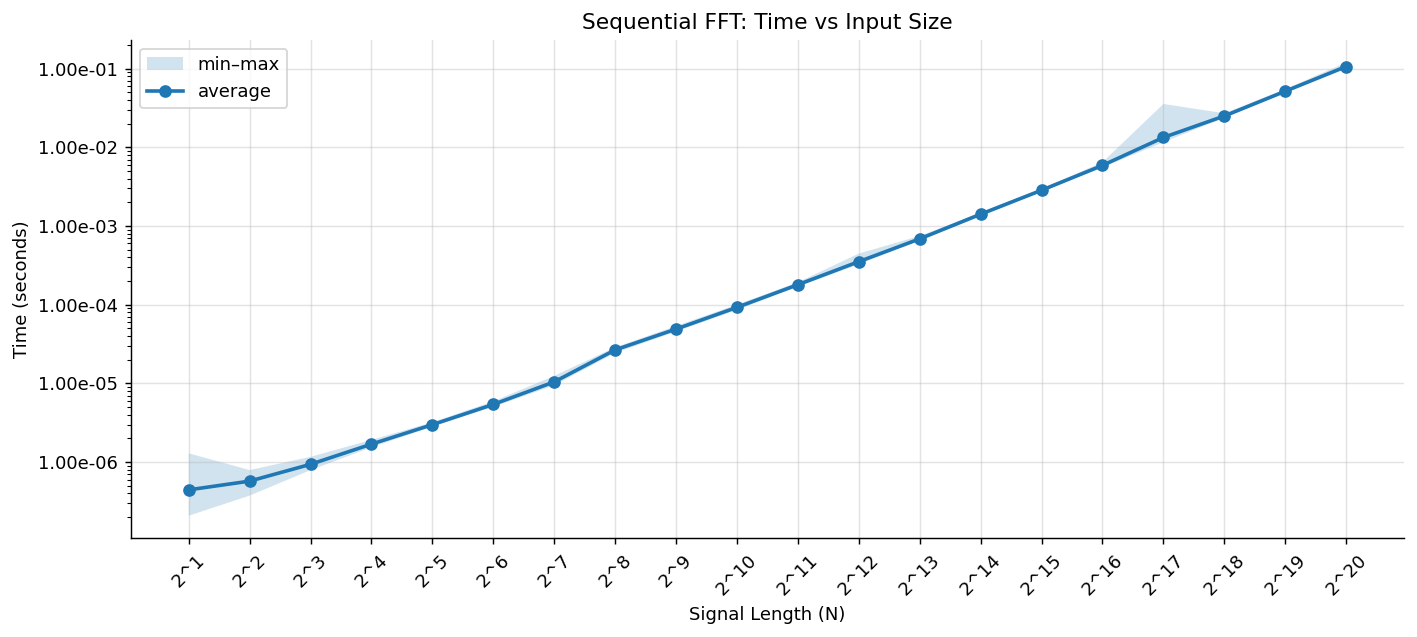

In [93]:
step_save_csv(results)
plot_results(results)

# Iterative Prallel

In [96]:
import subprocess
import os
import random
import re
import statistics
import time
import csv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ─────────────────────────────────────────────
#  CONFIG  — edit before running
# ─────────────────────────────────────────────
CPP_FILE      = "/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/cooley_tukey_iterative_optimized.cpp" # <--- UPDATE THIS to your C++ file name
BINARY        = "./fft_iter_bin"
NUM_RUNS      = 20                           # Reduced to 10 for faster sweeping
COMPILE_FLAGS = ["-O3", "-std=c++17", "-pthread"] # Added -pthread and -O3
CSV_FILE      = "iterative_parallel.csv" 

SIGNAL_LENGTHS = [2**p for p in range(1, 21)]  # 2^10 up to 2^24 (adjust as needed)
THREAD_COUNTS  = [2**p for p in range(0, 7)] 
# ─────────────────────────────────────────────

plt.rcParams.update({
    "figure.dpi"       : 130,
    "axes.grid"        : True,
    "grid.alpha"       : 0.35,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

# ── Step 1: Compile ───────────────────────────────────────────
def step_compile():
    assert os.path.isfile(CPP_FILE), f"'{CPP_FILE}' not found — check CPP_FILE config."
    cmd = ["g++", CPP_FILE, "-o", BINARY] + COMPILE_FLAGS
    print("Compiling:", " ".join(cmd))
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(f"[COMPILE ERROR]\n{res.stderr}")
    print("[OK] Compiled successfully.\n")

# ── Step 2: Run sweep ─────────────────────────────────────────
def build_input(signal_length: int, num_threads: int) -> str:
    """Instantly builds the input string since data generation is internal now."""
    return f"{signal_length}\n{num_threads}\n"

def parse_time(output: str):
    m = re.search(r"Time:\s*([\d.eE+\-]+)\s*seconds", output)
    return float(m.group(1)) if m else None

def run_once(stdin_data: str):
    try:
        r = subprocess.run(
            [BINARY], input=stdin_data,
            capture_output=True, text=True, timeout=120
        )
        if r.returncode != 0:
            print(f"  [CRASH] Exit code {r.returncode}")
            return None
            
        time_val = parse_time(r.stdout)
        if time_val is None:
            print("  [REGEX FAILED] Couldn't find time in STDOUT.")
            return None
            
        return time_val
    except subprocess.TimeoutExpired:
        print("  [TIMEOUT]")
        return None

def run_benchmark(threads: int, length: int) -> dict:
    data = build_input(length, threads)
    run_once(data) # warm-up (discarded)
    
    times = [t for _ in range(NUM_RUNS) if (t := run_once(data)) is not None]
    
    if not times:
        return dict(threads=threads, length=length,
                    avg=None, stdev=None, min=None, max=None, valid=0)
    return dict(
        threads = threads,
        length  = length,
        avg     = statistics.mean(times),
        stdev   = statistics.stdev(times) if len(times) > 1 else 0.0,
        min     = min(times),
        max     = max(times),
        valid   = len(times),
    )

def step_sweep() -> list[dict]:
    total   = len(SIGNAL_LENGTHS) * len(THREAD_COUNTS)
    results = []
    done    = 0
    t0      = time.time()

    print(f"Sweep: {len(SIGNAL_LENGTHS)} lengths × {len(THREAD_COUNTS)} thread configs "
          f"× {NUM_RUNS} runs = {total * NUM_RUNS} total launches\n")

    for length in SIGNAL_LENGTHS:
        for threads in THREAD_COUNTS:
            done += 1
            elapsed = time.time() - t0
            eta     = (elapsed / done) * (total - done) if done > 1 else 0

            print(f"[{done:>3}/{total}] N=2^{length.bit_length()-1:<2}={length:<9} "
                  f"T={threads:<2} | elapsed={elapsed:5.1f}s ETA~{eta:4.0f}s", end=" ")

            r = run_benchmark(threads, length)
            results.append(r)

            if r["avg"] is not None:
                print(f"| avg={r['avg']:.6f}s (ok={r['valid']}/{NUM_RUNS})")
            else:
                print("| FAILED")

    print(f"\nAll done in {time.time()-t0:.1f}s")
    return results

# ── Step 3: Save CSV ──────────────────────────────────────────
def step_save_csv(results: list[dict]):
    fieldnames = ["threads", "length", "avg", "stdev", "min", "max", "valid"]
    with open(CSV_FILE, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(results)
    print(f"[CSV] Saved {len(results)} rows → {CSV_FILE}\n")

# ── Step 4: Plots ─────────────────────────────────────────────
def plot_fixed_threads(results: list[dict], target_threads: int = 16):
    rows = sorted([r for r in results if r["threads"] == target_threads and r["avg"] is not None], key=lambda r: r["length"])
    if not rows: return

    xi    = list(range(len(rows)))
    xlabs = [f"2^{r['length'].bit_length()-1}" for r in rows]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(xi, [r["min"] for r in rows], [r["max"] for r in rows], alpha=0.2, color="steelblue")
    ax.plot(xi, [r["avg"] for r in rows], "o-", color="steelblue", linewidth=2, label=f"Avg Time")

    ax.set_xticks(xi)
    ax.set_xticklabels(xlabs, rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("Signal Length (N)", fontsize=11)
    ax.set_ylabel("Time (seconds)", fontsize=11)
    ax.set_title(f"Iterative FFT Scaling (Threads = {target_threads})", fontsize=13, fontweight="bold")
    ax.set_yscale("log")
    plt.tight_layout()
    plt.savefig("scaling_fixed_threads.png")
    plt.show()

def plot_fixed_size(results: list[dict], target_exp: int = 22):
    target_length = 2 ** target_exp
    rows = sorted([r for r in results if r["length"] == target_length and r["avg"] is not None], key=lambda r: r["threads"])
    if not rows: return

    xi    = list(range(len(rows)))
    y_avg = [r["avg"] for r in rows]
    ideal = [y_avg[0] / r["threads"] for r in rows] # Ideal linear scaling from T=1

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(xi, [r["min"] for r in rows], [r["max"] for r in rows], alpha=0.2, color="tomato")
    ax.plot(xi, y_avg, "s-", color="tomato", linewidth=2, label=f"Measured Time")
    ax.plot(xi, ideal, "--", color="gray", linewidth=1.5, label="Ideal Linear Speedup")

    ax.set_xticks(xi)
    ax.set_xticklabels([str(r["threads"]) for r in rows], fontsize=10)
    ax.set_xlabel("Thread Count", fontsize=11)
    ax.set_ylabel("Time (seconds)", fontsize=11)
    ax.set_title(f"Iterative FFT Speedup (N = 2^{target_exp})", fontsize=13, fontweight="bold")
    ax.set_yscale("log")
    ax.legend()
    plt.tight_layout()
    plt.savefig("speedup_fixed_size.png")
    plt.show()


In [97]:
step_compile()
res = step_sweep()
step_save_csv(res)


AssertionError: '/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/cooley_tukey_iterative_optimized.cpp' not found — check CPP_FILE config.

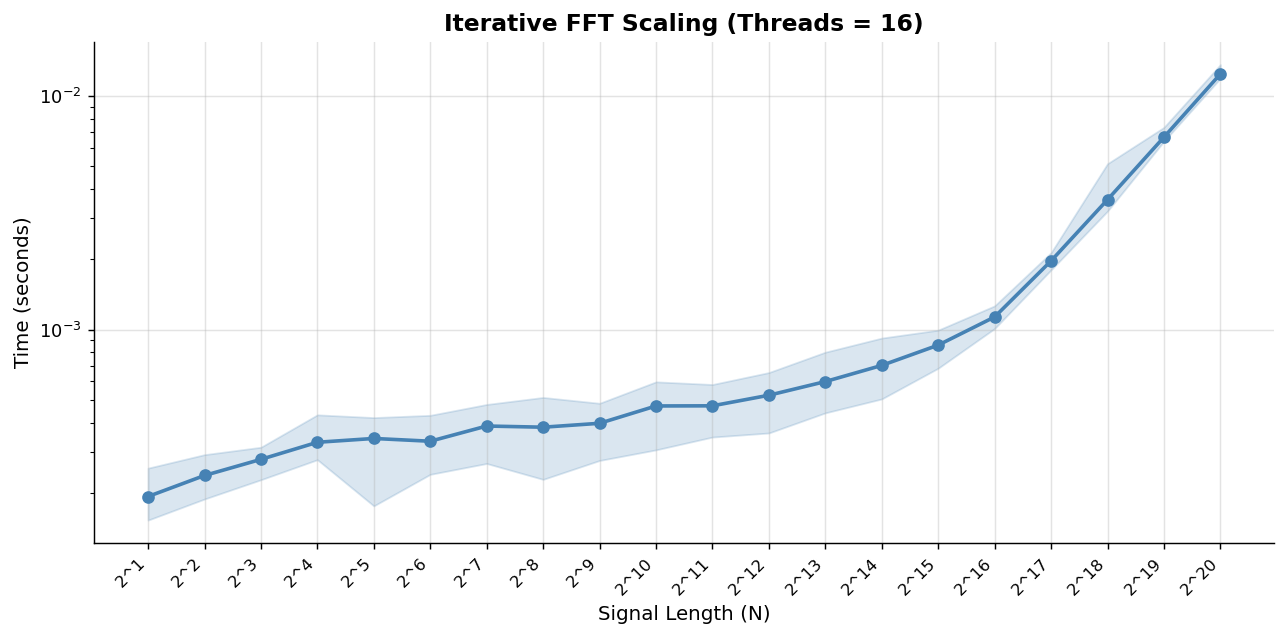

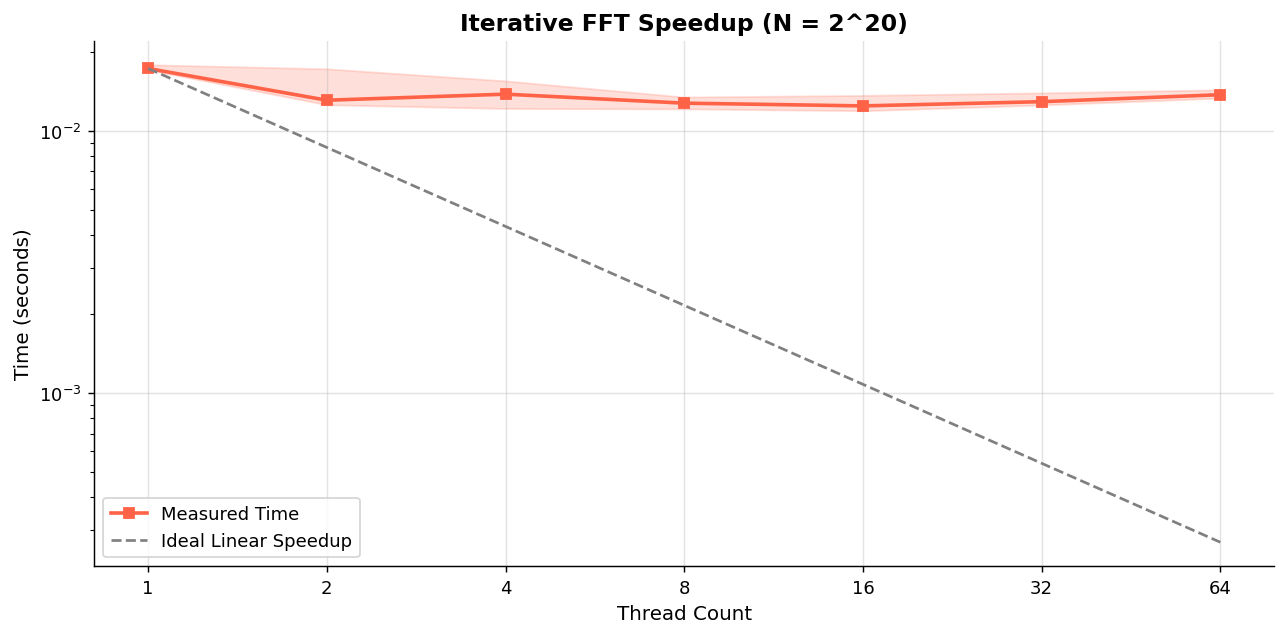

In [ ]:
plot_fixed_threads(res, target_threads=16) 
plot_fixed_size(res, target_exp=20)

In [ ]:
import csv
import math

# Load sequential data
seq_data = {}
# Updated file path for sequential iterative data
with open("sequential_iterative_fft.csv") as f:
    for row in csv.DictReader(f):
        length = int(row["length"])
        avg = float(row["avg"])
        seq_data[length] = avg

# Load parallel data
par_data = {}
# Updated file path for parallel iterative data
with open("iterative_parallel.csv") as f:
    for row in csv.DictReader(f):
        threads = int(row["threads"])
        size = int(row["length"])
        avg_str = row["avg"].strip()
        if avg_str != "nan" and avg_str != "":
            avg = float(avg_str)
            par_data[(threads, size)] = avg

# Find overlapping sizes
overlap = sorted(set(s for t, s in par_data.keys() if s in seq_data))
all_threads = sorted(set(t for t, s in par_data.keys()))

print("=" * 90)
print("SPEEDUP ANALYSIS (Iterative Sequential / Iterative Parallel)")
print("=" * 90)
print()

# For each thread count, show speedup across sizes
for thread_count in all_threads:
    print(f"\n{'THREADS: ' + str(thread_count):=^90}")
    print(f"{'Signal Size':>15} | {'Power':>5} | {'Seq Time':>12} | {'Par Time':>12} | {'Speedup':>10}")
    print("-" * 90)
    
    for size in overlap:
        if (thread_count, size) in par_data:
            seq_time = seq_data[size]
            par_time = par_data[(thread_count, size)]
            speedup = seq_time / par_time
            power = int(math.log2(size))
            
            print(f"{size:>15} | {power:>5} | {seq_time:>12.6e} | {par_time:>12.6e} | {speedup:>10.4f}x")

print("\n" + "=" * 90)

SPEEDUP ANALYSIS (Iterative Sequential / Iterative Parallel)


========================================THREADS: 1========================================
    Signal Size | Power |     Seq Time |     Par Time |    Speedup
------------------------------------------------------------------------------------------
              2 |     1 | 1.563000e-07 | 2.504370e-05 |     0.0062x
              4 |     2 | 1.748500e-07 | 1.490215e-05 |     0.0117x
              8 |     3 | 2.311500e-07 | 1.520825e-05 |     0.0152x
             16 |     4 | 3.499000e-07 | 1.563130e-05 |     0.0224x
             32 |     5 | 4.896000e-07 | 1.634165e-05 |     0.0300x
             64 |     6 | 8.957500e-07 | 1.720220e-05 |     0.0521x
            128 |     7 | 1.558250e-06 | 1.754165e-05 |     0.0888x
            256 |     8 | 3.116550e-06 | 2.171460e-05 |     0.1435x
            512 |     9 | 6.164500e-06 | 2.408125e-05 |     0.2560x
           1024 |    10 | 1.413545e-05 | 2.957710e-05 |     0.4779x
        

# Recursive Parallel

In [98]:
import subprocess
import os
import sys
import random
import re
import statistics
import time
import csv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [99]:
# ─────────────────────────────────────────────
#  CONFIG  — edit before running
# ─────────────────────────────────────────────
CPP_FILE      = "/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/cooley_tukey_recursive_parallel.c++"
BINARY        = "./fft_rec_bin"
NUM_RUNS      = 20
COMPILE_FLAGS = ["-O2", "-std=c++17"]
CSV_FILE      = "recursive_parallel.csv"   # output CSV name

SIGNAL_LENGTHS = [2**p for p in range(1, 21)]   # 2^1 … 2^20
THREAD_COUNTS  = [2**p for p in range(0, 7)]    # 1, 2, 4, 8, 16, 32, 64
# ─────────────────────────────────────────────

In [100]:




plt.rcParams.update({
    "figure.dpi"       : 130,
    "axes.grid"        : True,
    "grid.alpha"       : 0.35,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

# ── Step 1: Compile ───────────────────────────────────────────
def step_compile():
    assert os.path.isfile(CPP_FILE), f"'{CPP_FILE}' not found — check CPP_FILE config."
    cmd = ["g++", CPP_FILE, "-o", BINARY] + COMPILE_FLAGS
    print("Compiling:", " ".join(cmd))
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(f"[COMPILE ERROR]\n{res.stderr}")
    print("[OK] Compiled successfully.\n")

# ── Step 2: Run sweep ─────────────────────────────────────────
_cache: dict[int, str] = {}

def build_input(signal_length: int, num_threads: int) -> str:
    """Input order: signal_length -> num_threads"""
    return f"{signal_length}\n{num_threads}\n"
def parse_time(output: str):
    # Changed "seconds" to "s"
    m = re.search(r"Time:\s*([\d.eE+\-]+)\s*s", output)
    return float(m.group(1)) if m else None

def run_once(stdin_data: str):
    try:
        r = subprocess.run(
            [BINARY], input=stdin_data,
            capture_output=True, text=True, timeout=120
        )
        return parse_time(r.stdout) if r.returncode == 0 else None
    except subprocess.TimeoutExpired:
        return None

def run_benchmark(threads: int, length: int) -> dict:
    data = build_input(length, threads)
    run_once(data)                                       # warm-up (discarded)
    times = [t for _ in range(NUM_RUNS)
               if (t := run_once(data)) is not None]
    if not times:
        return dict(threads=threads, length=length,
                    avg=None, stdev=None, min=None, max=None, valid=0)
    return dict(
        threads = threads,
        length  = length,
        avg     = statistics.mean(times),
        stdev   = statistics.stdev(times) if len(times) > 1 else 0.0,
        min     = min(times),
        max     = max(times),
        valid   = len(times),
    )

def step_sweep() -> list[dict]:
    total   = len(SIGNAL_LENGTHS) * len(THREAD_COUNTS)
    results = []
    done    = 0
    t0      = time.time()

    print(f"Sweep: {len(SIGNAL_LENGTHS)} lengths × {len(THREAD_COUNTS)} thread configs "
          f"× {NUM_RUNS} runs = {total * NUM_RUNS} total launches\n")

    for length in SIGNAL_LENGTHS:
        for threads in THREAD_COUNTS:
            done += 1
            elapsed = time.time() - t0
            eta     = (elapsed / done) * (total - done) if done > 1 else 0

            print(f"[{done:>3}/{total}]  N=2^{length.bit_length()-1:<2}={length:<8}  "
                  f"T={threads:<4}  elapsed={elapsed:6.1f}s  ETA~{eta:5.0f}s", end="  ")

            r = run_benchmark(threads, length)
            results.append(r)

            if r["avg"] is not None:
                print(f"avg={r['avg']:.6f}s  ok={r['valid']}/{NUM_RUNS}")
            else:
                print("FAILED")

    print(f"\nAll done in {time.time()-t0:.1f}s")
    return results

# ── Step 3: Save CSV ──────────────────────────────────────────
def step_save_csv(results: list[dict]):
    fieldnames = ["threads", "length", "avg", "stdev", "min", "max", "valid"]
    with open(CSV_FILE, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(results)
    print(f"[CSV] Saved {len(results)} rows → {CSV_FILE}\n")

# ── Step 4: Plots ─────────────────────────────────────────────
def plot_fixed_threads(results: list[dict], target_threads: int = 16):
    rows = sorted(
        [r for r in results if r["threads"] == target_threads and r["avg"] is not None],
        key=lambda r: r["length"]
    )
    if not rows:
        print(f"No data for threads={target_threads}")
        return

    xi    = list(range(len(rows)))
    xlabs = [f"2^{r['length'].bit_length()-1}" for r in rows]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.fill_between(xi, [r["min"] for r in rows], [r["max"] for r in rows],
                    alpha=0.18, color="steelblue", label="min–max band")
    ax.plot(xi, [r["avg"] for r in rows], "o-", color="steelblue",
            linewidth=2, markersize=5, label=f"avg ({NUM_RUNS} runs)")

    ax.set_xticks(xi)
    ax.set_xticklabels(xlabs, rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("Signal Length (N)", fontsize=11)
    ax.set_ylabel("Time (seconds)", fontsize=11)
    ax.set_title(f"FFT Time vs Signal Size  |  Threads = {target_threads}",
                 fontsize=13, fontweight="bold")
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2e"))
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_fixed_size(results: list[dict], target_exp: int = 20):
    target_length = 2 ** target_exp
    rows = sorted(
        [r for r in results if r["length"] == target_length and r["avg"] is not None],
        key=lambda r: r["threads"]
    )
    if not rows:
        print(f"No data for length=2^{target_exp}")
        return

    xi    = list(range(len(rows)))
    y_avg = [r["avg"] for r in rows]
    ideal = [y_avg[0] / r["threads"] for r in rows]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.fill_between(xi, [r["min"] for r in rows], [r["max"] for r in rows],
                    alpha=0.18, color="tomato", label="min–max range")
    ax.plot(xi, y_avg, "s-", color="tomato",
            linewidth=2, markersize=6, label=f"avg ({NUM_RUNS} runs)")
    ax.plot(xi, ideal, "--", color="gray",
            linewidth=1.5, label="ideal linear speedup")

    ax.set_xticks(xi)
    ax.set_xticklabels([str(r["threads"]) for r in rows], fontsize=10)
    ax.set_xlabel("Thread Count", fontsize=11)
    ax.set_ylabel("Time (seconds)", fontsize=11)
    ax.set_title(f"FFT Time vs Thread Count  |  N = 2^{target_exp} = {target_length:,}",
                 fontsize=13, fontweight="bold")
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2e"))
    ax.legend()
    plt.tight_layout()
    plt.show()

# ── Entry point ───────────────────────────────────────────────


In [101]:
step_compile()
results = step_sweep()
step_save_csv(results)          # ← saves to iterative_parallel.csv

AssertionError: '/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/cooley_tukey_recursive_parallel.c++' not found — check CPP_FILE config.

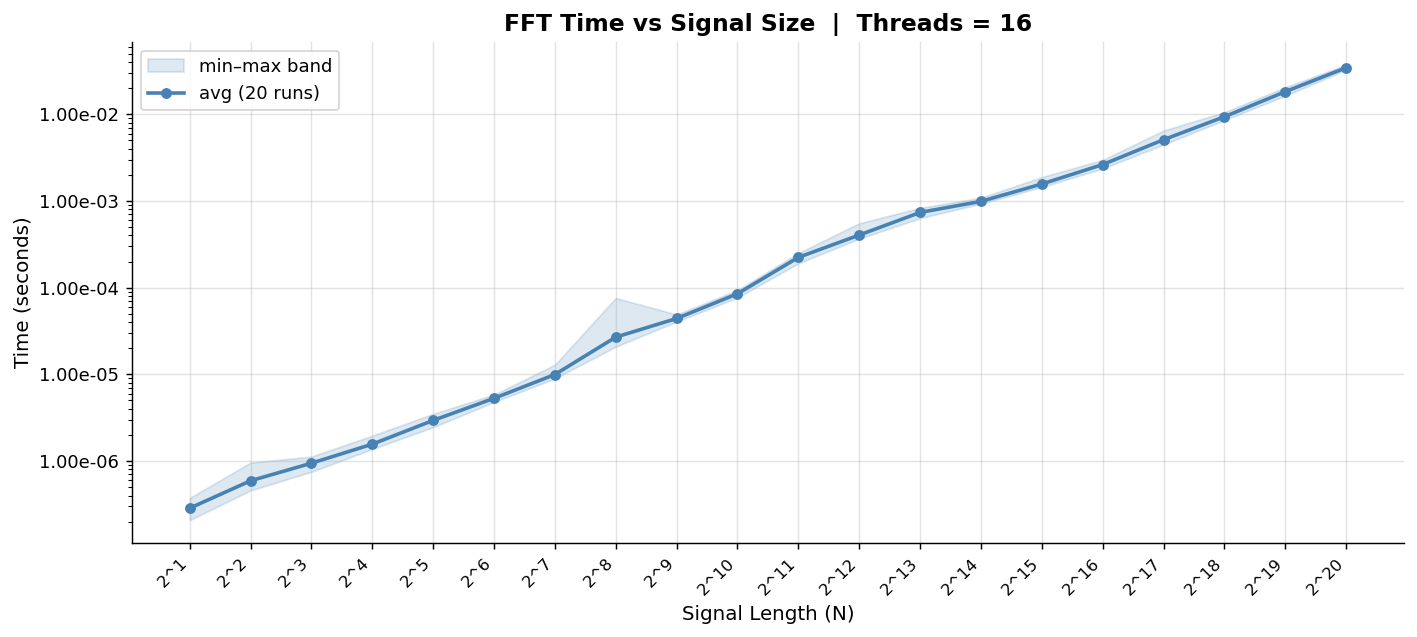

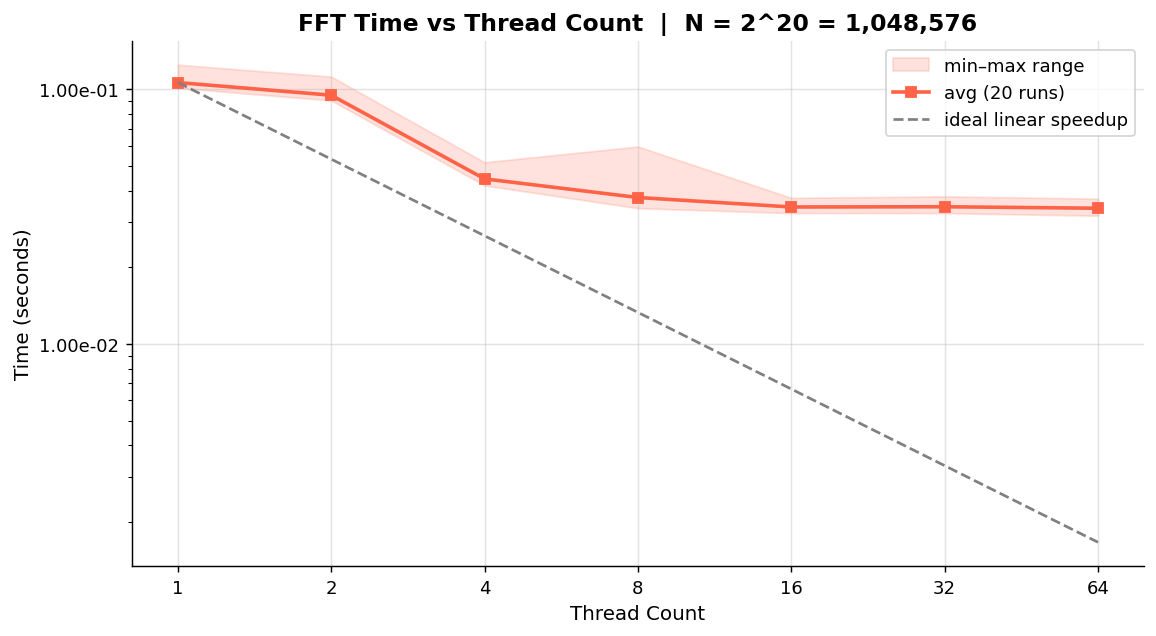

In [ ]:
plot_fixed_threads(results, target_threads=16)
plot_fixed_size(results,   target_exp=20)

In [ ]:
import csv
import math

# Load sequential data
seq_data = {}
with open("sequential_fft.csv") as f:
    for row in csv.DictReader(f):
        length = int(row["length"])
        avg = float(row["avg"])
        seq_data[length] = avg

# Load parallel data
par_data = {}
with open("recursive_parallel.csv") as f:
    for row in csv.DictReader(f):
        threads = int(row["threads"])
        size = int(row["length"])
        avg_str = row["avg"].strip()
        if avg_str != "nan" and avg_str != "":
            avg = float(avg_str)
            par_data[(threads, size)] = avg

# Find overlapping sizes
overlap = sorted(set(s for t, s in par_data.keys() if s in seq_data))
all_threads = sorted(set(t for t, s in par_data.keys()))

print("=" * 90)
print("SPEEDUP ANALYSIS (Sequential / Parallel)")
print("=" * 90)
print()

# For each thread count, show speedup across sizes
for thread_count in all_threads:
    print(f"\n{'THREADS: ' + str(thread_count):=^90}")
    print(f"{'Signal Size':>15} | {'Power':>5} | {'Seq Time':>12} | {'Par Time':>12} | {'Speedup':>10}")
    print("-" * 90)
    
    for size in overlap:
        if (thread_count, size) in par_data:
            seq_time = seq_data[size]
            par_time = par_data[(thread_count, size)]
            speedup = seq_time / par_time
            power = int(math.log2(size))
            
            print(f"{size:>15} | {power:>5} | {seq_time:>12.6e} | {par_time:>12.6e} | {speedup:>10.4f}x")

print("\n" + "=" * 90)



SPEEDUP ANALYSIS (Sequential / Parallel)


========================================THREADS: 1========================================
    Signal Size | Power |     Seq Time |     Par Time |    Speedup
------------------------------------------------------------------------------------------
              2 |     1 | 4.168500e-07 | 3.688000e-07 |     1.1303x
              4 |     2 | 7.541500e-07 | 6.145500e-07 |     1.2272x
              8 |     3 | 1.014650e-06 | 9.478500e-07 |     1.0705x
             16 |     4 | 2.441850e-06 | 1.841650e-06 |     1.3259x
             32 |     5 | 3.189600e-06 | 3.029100e-06 |     1.0530x
             64 |     6 | 5.381200e-06 | 5.185350e-06 |     1.0378x
            128 |     7 | 1.497090e-05 | 9.858400e-06 |     1.5186x
            256 |     8 | 2.494170e-05 | 2.461455e-05 |     1.0133x
            512 |     9 | 4.848740e-05 | 4.383130e-05 |     1.1062x
           1024 |    10 | 1.013063e-04 | 8.862300e-05 |     1.1431x
           2048 |    11 | 1.

# Iterative

In [ ]:
import subprocess
import random
import time
import csv
import os
import sys

In [ ]:

CPP_FILE      = "/Users/yashwanth/Desktop/IITH/SEM 6/PCP/project/Project/src/cooley_tukey_iterative_optimized.cpp"
BINARY        = "./iterative_parallel"
OUTPUT_CSV = "iterative_parallel.csv"

THREAD_COUNTS = [1, 2, 4, 8, 16, 32, 64, 128]
SIGNAL_POWERS = list(range(0, 26))  # 2^0 to 2^20
NUM_RUNS = 10
TIMEOUT = 60  # seconds per run, kill if stuck


def compile_code():
    print("Compiling...")
    result = subprocess.run(
        ["g++", "-O2", "-std=c++17", "-pthread", "-o", BINARY, CPP_FILE],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f"Compilation failed:\n{result.stderr}")
        sys.exit(1)
    print("Compiled successfully.\n")


def generate_input(num_threads, signal_size):
    """Generate input string: num_threads, signal_size, then random floats."""
    values = [f"{random.uniform(-100, 100):.6f}" for _ in range(signal_size)]
    return f"{num_threads}\n{signal_size}\n" + "\n".join(values) + "\n"


def parse_time(output):
    """Extract time from 'Time: X seconds' line."""
    for line in output.strip().split("\n"):
        if line.startswith("Time:"):
            return float(line.split()[1])
    return None


def run_single(num_threads, signal_size, input_data):
    """Run once, return elapsed time or None on failure."""
    try:
        result = subprocess.run(
            [BINARY],
            input=input_data,
            capture_output=True,
            text=True,
            timeout=TIMEOUT
        )
        if result.returncode != 0:
            return None
        return parse_time(result.stdout)
    except subprocess.TimeoutExpired:
        return None
    except Exception as e:
        print(f"  Error: {e}")
        return None


def main():
    compile_code()

    results = []
    total_configs = len(THREAD_COUNTS) * len(SIGNAL_POWERS)
    config_num = 0

    # Pre-generate one input per signal size (reuse across threads/runs for consistency)
    print("Pre-generating inputs...")
    inputs = {}
    for p in SIGNAL_POWERS:
        size = 1 << p
        # Generate a single set of values, format per-thread-count later
        values = [f"{random.uniform(-100, 100):.6f}" for _ in range(size)]
        inputs[p] = values
    print("Done.\n")

    print(f"{'Threads':>8} {'Size':>10} {'Avg Time (s)':>14} {'Min':>12} {'Max':>12} {'Runs':>5}")
    print("-" * 65)

    for p in SIGNAL_POWERS:
        size = 1 << p
        for t in THREAD_COUNTS:
            config_num += 1

            # Skip if threads > signal size (pointless)
            if t > size:
                continue

            input_data = f"{t}\n{size}\n" + "\n".join(inputs[p]) + "\n"

            times = []
            for run in range(NUM_RUNS):
                elapsed = run_single(t, size, input_data)
                if elapsed is not None:
                    times.append(elapsed)

            if times:
                avg_time = sum(times) / len(times)
                min_time = min(times)
                max_time = max(times)
            else:
                avg_time = min_time = max_time = float('nan')

            print(f"{t:>8} {size:>10} {avg_time:>14.6f} {min_time:>12.6f} {max_time:>12.6f} {len(times):>5}")

            results.append({
                "threads": t,
                "signal_size": size,
                "signal_power": p,
                "avg_time": avg_time,
                "min_time": min_time,
                "max_time": max_time,
                "successful_runs": len(times),
            })

    # Write CSV
    with open(OUTPUT_CSV, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=results[0].keys())
        writer.writeheader()
        writer.writerows(results)

    print(f"\nResults saved to {OUTPUT_CSV}")


if __name__ == "__main__":
    main()

Compiling...
Compiled successfully.

Pre-generating inputs...
Done.

 Threads       Size   Avg Time (s)          Min          Max  Runs
-----------------------------------------------------------------
       1          1       0.000031     0.000017     0.000053    10
       1          2       0.000017     0.000014     0.000020    10
       2          2       0.000027     0.000024     0.000030    10
       1          4       0.000018     0.000015     0.000023    10
       2          4       0.000028     0.000025     0.000030    10
       4          4       0.000046     0.000042     0.000058    10
       1          8       0.000018     0.000016     0.000021    10
       2          8       0.000032     0.000028     0.000042    10
       4          8       0.000061     0.000049     0.000071    10
       8          8       0.000143     0.000122     0.000179    10
       1         16       0.000017     0.000016     0.000021    10
       2         16       0.000048     0.000034     0.000100 

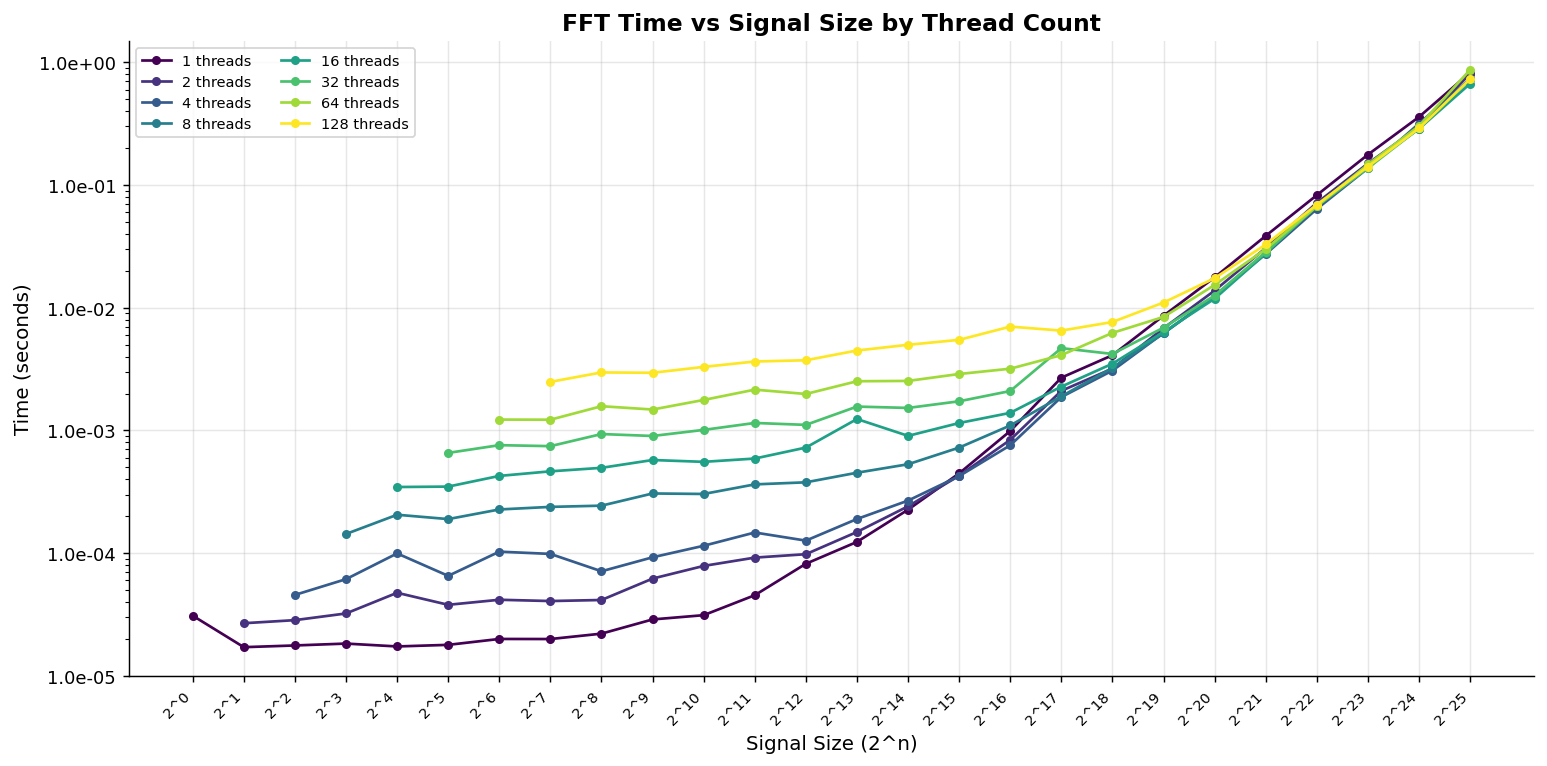

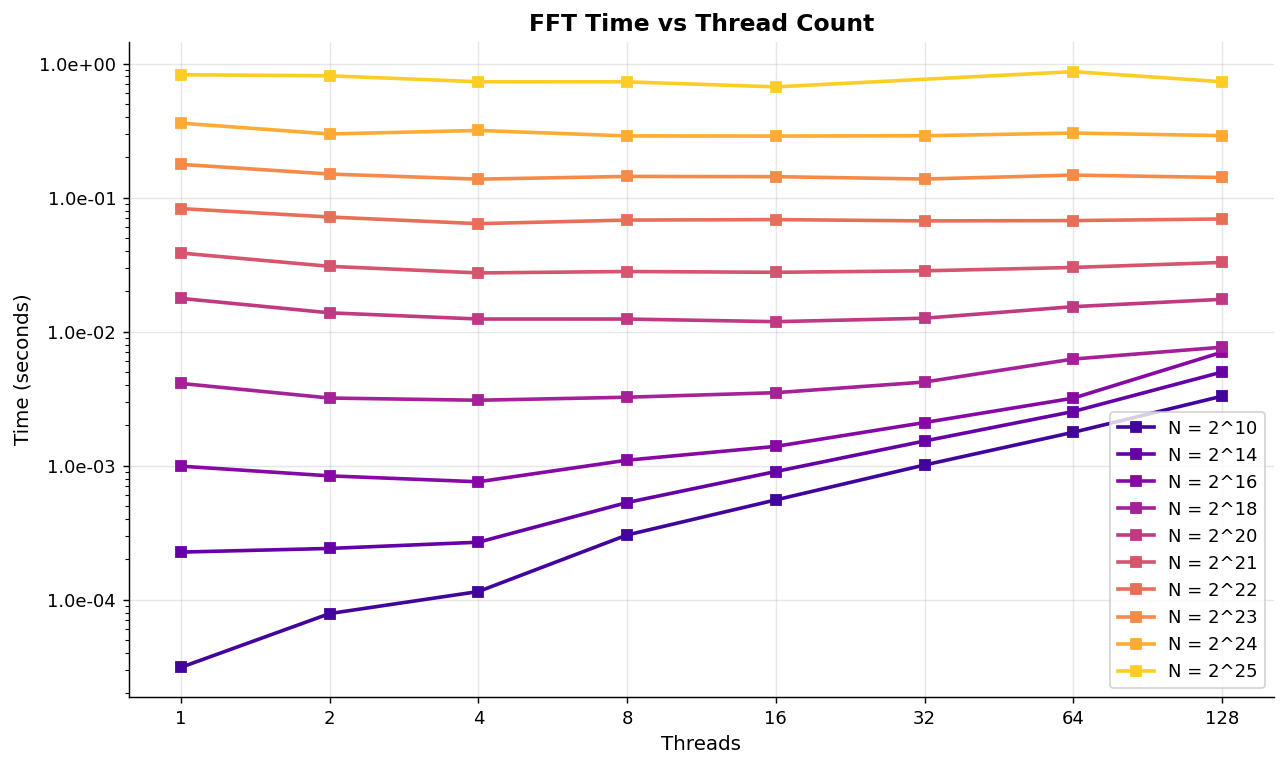

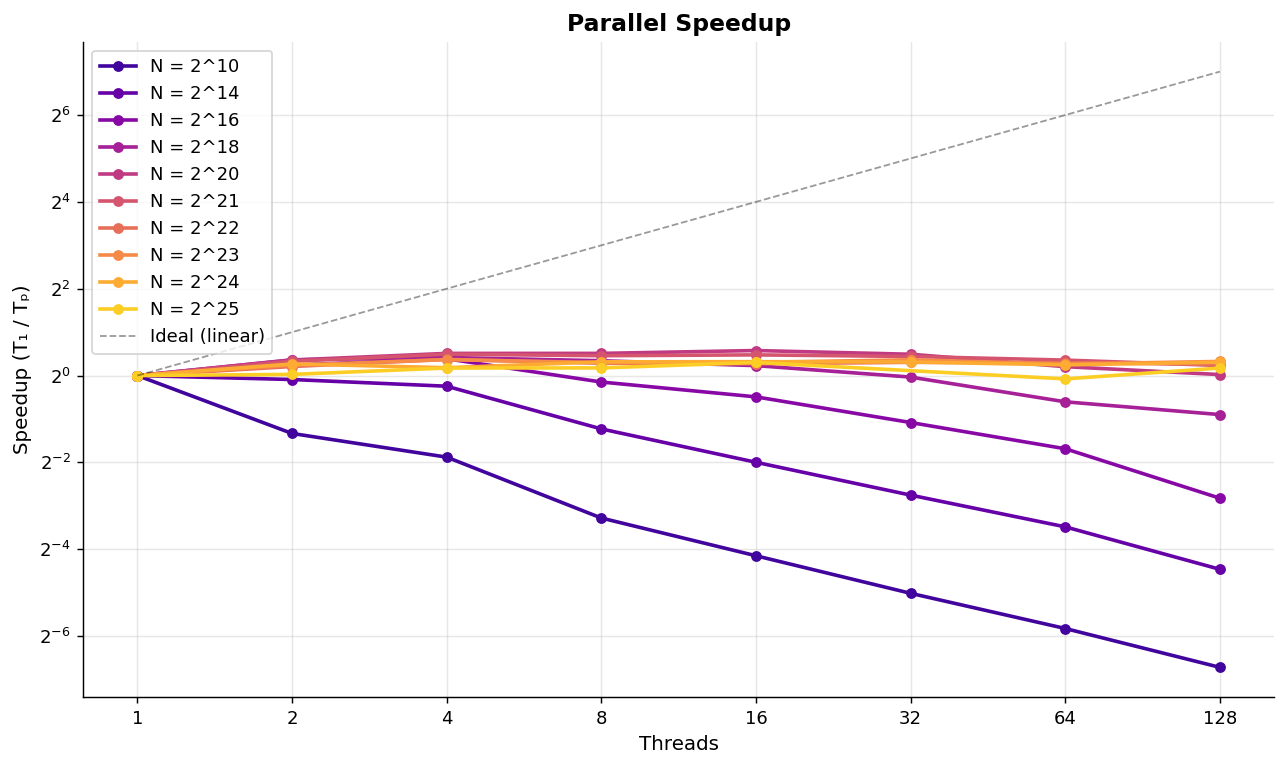

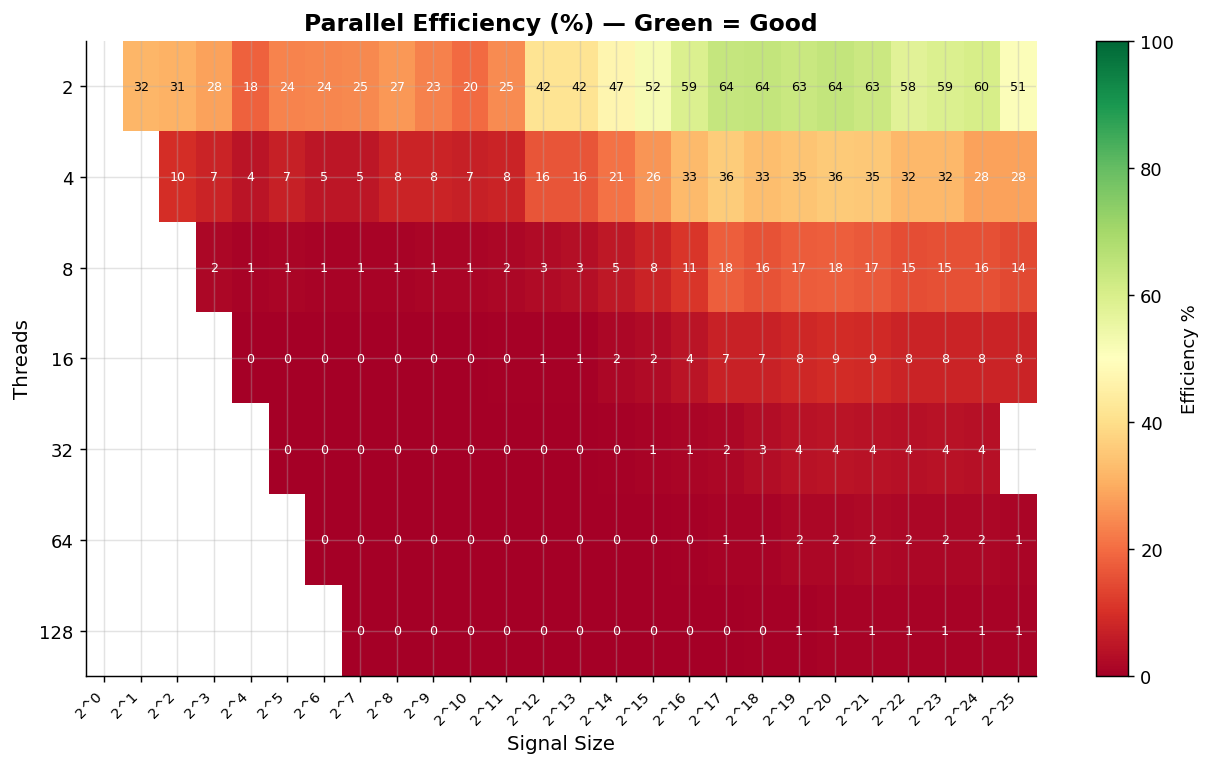

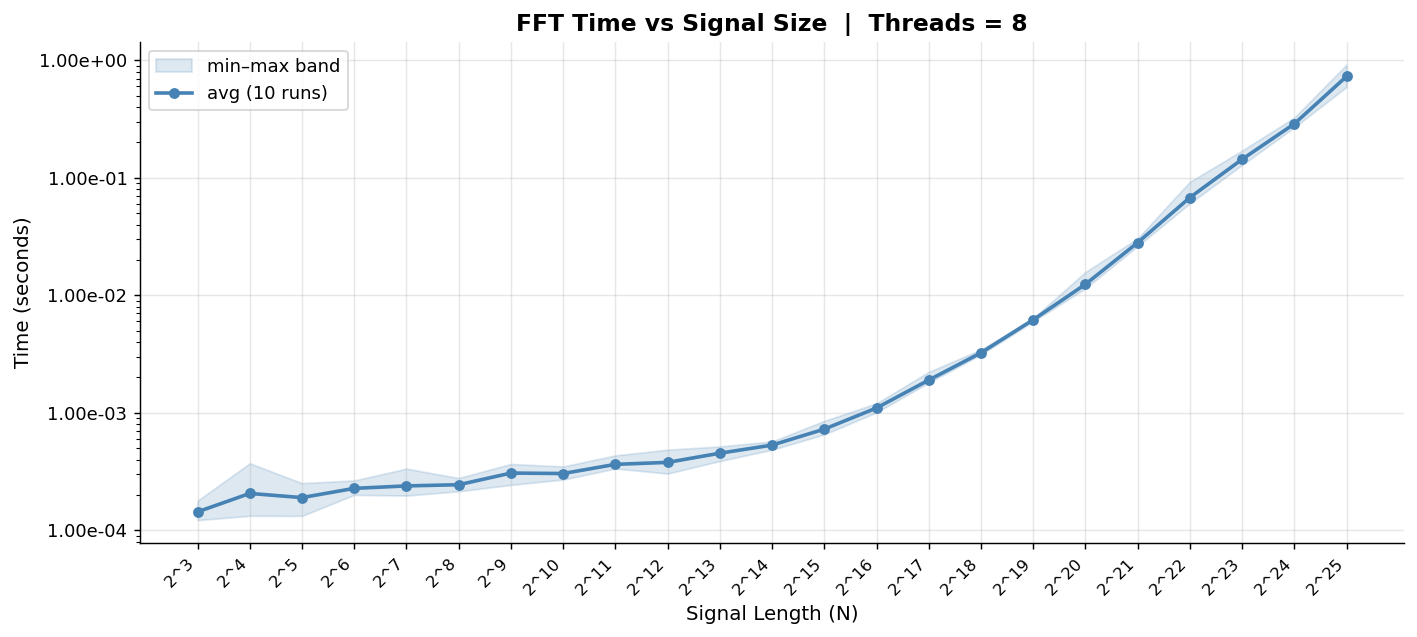

All plots saved.


In [ ]:
import csv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

CSV_FILE = "iterative_parallel.csv"

# ── Load data ───────────────────────────────────────────────
with open(CSV_FILE) as f:
    reader = csv.DictReader(f)
    results = []
    for r in reader:
        results.append({
            'threads': int(r['threads']),
            'size':    int(r['signal_size']),
            'power':   int(r['signal_power']),
            'avg':     float(r['avg_time']),
            'min':     float(r['min_time']),
            'max':     float(r['max_time']),
            'runs':    int(r['successful_runs']),
        })

# Filter out failed runs
results = [r for r in results if r['runs'] > 0 and not np.isnan(r['avg'])]

all_threads = sorted(set(r['threads'] for r in results))
all_powers  = sorted(set(r['power']  for r in results))

# ── Plot 1: Time vs Signal Size (one line per thread count) ─
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(all_threads)))

for i, t in enumerate(all_threads):
    rows = sorted([r for r in results if r['threads'] == t], key=lambda r: r['power'])
    if not rows:
        continue
    x = [r['power'] for r in rows]
    y = [r['avg']   for r in rows]
    ax.plot(x, y, 'o-', color=colors[i], linewidth=1.5, markersize=4, label=f'{t} threads')

ax.set_xlabel('Signal Size (2^n)', fontsize=11)
ax.set_ylabel('Time (seconds)', fontsize=11)
ax.set_title('FFT Time vs Signal Size by Thread Count', fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
ax.set_xticks(all_powers)
ax.set_xticklabels([f'2^{p}' for p in all_powers], rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('plot1_time_vs_size.png', dpi=150)
plt.show()

# ── Plot 2: Time vs Threads for select signal sizes ────────
TARGET_POWERS = [p for p in [10, 14, 16, 18, 20, 21, 22, 23, 24, 25] if p in set(r['power'] for r in results)]
fig, ax = plt.subplots(figsize=(10, 6))
colors2 = plt.cm.plasma(np.linspace(0.1, 0.9, len(TARGET_POWERS)))

for i, p in enumerate(TARGET_POWERS):
    rows = sorted([r for r in results if r['power'] == p], key=lambda r: r['threads'])
    if not rows:
        continue
    x = [r['threads'] for r in rows]
    y = [r['avg']     for r in rows]
    ax.plot(x, y, 's-', color=colors2[i], linewidth=2, markersize=5, label=f'N = 2^{p}')

ax.set_xlabel('Threads', fontsize=11)
ax.set_ylabel('Time (seconds)', fontsize=11)
ax.set_title('FFT Time vs Thread Count', fontsize=13, fontweight='bold')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.set_xticks(all_threads)
ax.set_xticklabels(all_threads)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('plot2_time_vs_threads.png', dpi=150)
plt.show()

# ── Plot 3: Speedup vs Threads ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Get baseline (1 thread) times
baseline = {r['power']: r['avg'] for r in results if r['threads'] == 1}

for i, p in enumerate(TARGET_POWERS):
    if p not in baseline:
        continue
    rows = sorted([r for r in results if r['power'] == p], key=lambda r: r['threads'])
    x = [r['threads'] for r in rows]
    y = [baseline[p] / r['avg'] for r in rows]
    ax.plot(x, y, 'o-', color=colors2[i], linewidth=2, markersize=5, label=f'N = 2^{p}')

# Ideal speedup line
ax.plot(all_threads, all_threads, 'k--', alpha=0.4, linewidth=1, label='Ideal (linear)')

ax.set_xlabel('Threads', fontsize=11)
ax.set_ylabel('Speedup (T₁ / Tₚ)', fontsize=11)
ax.set_title('Parallel Speedup', fontsize=13, fontweight='bold')
ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.set_xticks(all_threads)
ax.set_xticklabels(all_threads)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('plot3_speedup.png', dpi=150)
plt.show()

# ── Plot 4: Efficiency heatmap ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Build efficiency matrix: efficiency = speedup / num_threads
powers_with_baseline = [p for p in all_powers if p in baseline]
threads_gt1 = [t for t in all_threads if t > 1]

efficiency = np.full((len(threads_gt1), len(powers_with_baseline)), np.nan)

lookup = {(r['threads'], r['power']): r['avg'] for r in results}

for i, t in enumerate(threads_gt1):
    for j, p in enumerate(powers_with_baseline):
        if (t, p) in lookup and (1, p) in lookup:
            speedup = lookup[(1, p)] / lookup[(t, p)]
            efficiency[i, j] = speedup / t * 100  # percentage

im = ax.imshow(efficiency, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
ax.set_xticks(range(len(powers_with_baseline)))
ax.set_xticklabels([f'2^{p}' for p in powers_with_baseline], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(threads_gt1)))
ax.set_yticklabels(threads_gt1)
ax.set_xlabel('Signal Size', fontsize=11)
ax.set_ylabel('Threads', fontsize=11)
ax.set_title('Parallel Efficiency (%) — Green = Good', fontsize=13, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Efficiency %')

# Annotate cells
for i in range(len(threads_gt1)):
    for j in range(len(powers_with_baseline)):
        val = efficiency[i, j]
        if not np.isnan(val):
            color = 'white' if val < 30 or val > 80 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
# plt.savefig('plot4_efficiency_heatmap.png', dpi=150)
plt.show()

# ── Plot 5: Fixed thread count, time with min-max band ─────
# Pick the thread count closest to your core count
TARGET_THREADS = 8  # change to match your Mac's core count

rows = sorted([r for r in results if r['threads'] == TARGET_THREADS], key=lambda r: r['power'])

if rows:
    fig, ax = plt.subplots(figsize=(11, 5))
    x     = list(range(len(rows)))
    y_avg = [r['avg'] for r in rows]
    y_min = [r['min'] for r in rows]
    y_max = [r['max'] for r in rows]
    xlabs = [f"2^{r['power']}" for r in rows]

    ax.fill_between(x, y_min, y_max, alpha=0.18, color='steelblue', label='min–max band')
    ax.plot(x, y_avg, 'o-', color='steelblue', linewidth=2, markersize=5, label=f'avg ({NUM_RUNS} runs)')

    ax.set_xticks(x)
    ax.set_xticklabels(xlabs, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel('Signal Length (N)', fontsize=11)
    ax.set_ylabel('Time (seconds)', fontsize=11)
    ax.set_title(f'FFT Time vs Signal Size  |  Threads = {TARGET_THREADS}', fontsize=13, fontweight='bold')
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig('plot5_time_band.png', dpi=150)
    plt.show()

print("All plots saved.")

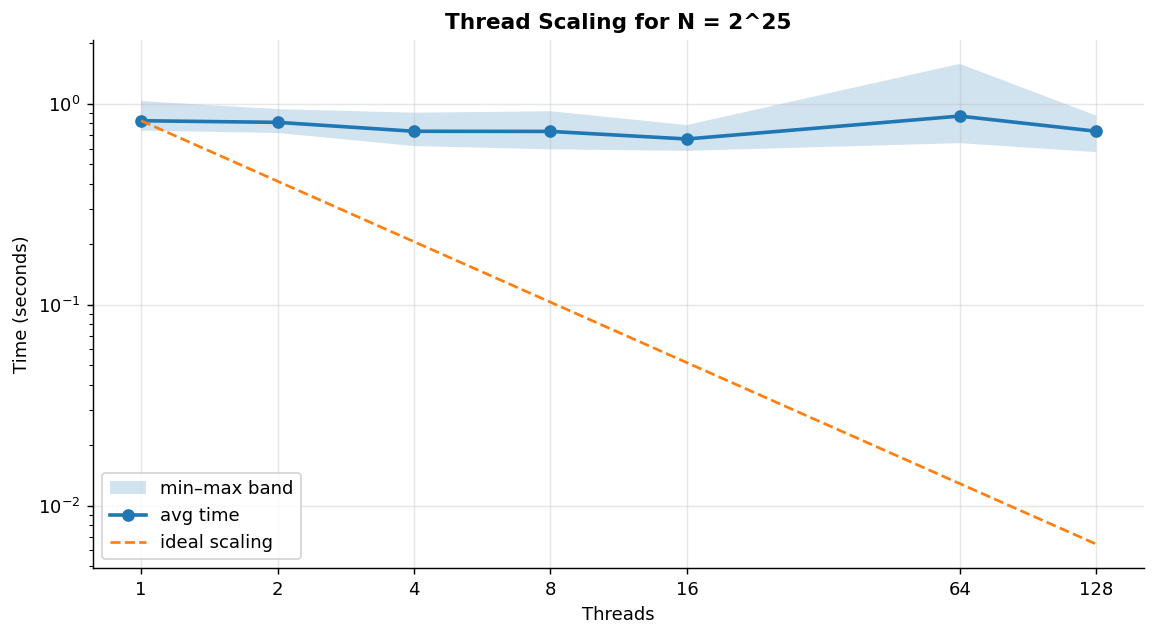

In [ ]:
# ── Plot 6: Threads vs Time for ONE specific input size ────

TARGET_POWER = 25   # 👈 change this (e.g., 18, 19, 20)

rows = sorted(
    [r for r in results if r['power'] == TARGET_POWER],
    key=lambda r: r['threads']
)

if not rows:
    print(f"No data for 2^{TARGET_POWER}")
else:
    fig, ax = plt.subplots(figsize=(9, 5))

    x = [r['threads'] for r in rows]
    y_avg = [r['avg'] for r in rows]
    y_min = [r['min'] for r in rows]
    y_max = [r['max'] for r in rows]

    # Ideal scaling
    base = y_avg[0]  # time at 1 thread
    ideal = [base / t for t in x]

    ax.fill_between(x, y_min, y_max, alpha=0.2, label="min–max band")
    ax.plot(x, y_avg, 'o-', linewidth=2, label="avg time")
    ax.plot(x, ideal, '--', linewidth=1.5, label="ideal scaling")

    ax.set_xscale('log', base=2)
    ax.set_yscale('log')

    ax.set_xlabel("Threads")
    ax.set_ylabel("Time (seconds)")
    ax.set_title(f"Thread Scaling for N = 2^{TARGET_POWER}", fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(x)

    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()